# Metacatalog association & quality-control summary

Pipeline census for the MHz-subband metacatalog (`CATALOG_DIR`): detections → LST merge → band merge → default QC → spectral fits → external associations.

| Metric | Definition |
| --- | --- |
| Per-image detections | All `sources_{lst}_{band}.parquet` rows (22 LST × 15 subbands) |
| LST-merged | One representative per sky position **within each subband** |
| Metacatalog | Global fusion after sequential subband merge |
| Default QC (`core_clean`) | `(quality_flag & EXCLUDE_MASK) == 0` with `EXCLUDE_MASK = 33267` |
| Spectral fit | `spec_model_n_flux >= 2` (Taylor fit about 55 MHz) |
| Good spectral fit | fitted and `spec_model_chi2_red < CHI2_RED_MAX` |
| Unique radio / NED-LVS | exactly one association (`n_* == 1`) |

**Reference counts** (compiled from notebook outputs / live Parquet; associations use LWA 1σ localization):

| Metric | Count |
| --- | ---: |
| Detections (all LST × subbands) | 6,195,000 |
| Metacatalog after band merge | 138,732 |
| Pass default QC | 128,352 |
| Spectral fit | 118,800 |
| Spectral fit, χ²_red < 5 | 107,558 |
| Unique VLSSR / NVSS / VLASS | 54,097 / 45,897 / 15,399 |
| Unique NED-LVS (`z ≤ 0.0223`) | 1,573 |

The Venn section compares **QC-cleared**, **spectral-fit**, and **unique match to VLSSR ∪ NVSS ∪ VLASS**.

**Run cells in order.** Association cells can reuse a cached flags Parquet (`REUSE_CACHED_ASSOCIATIONS`).


In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
from IPython.display import display
from matplotlib.patches import Circle

from lwa_catalog import CatalogLayout, read_metacatalog, resolve_metacatalog_path
from lwa_catalog.analyze import (
    CrossmatchRadiusSpec,
    NedlvsMatchConfig,
    NvssMatchConfig,
    NVSS_REFERENCE_RADIUS_LOCALIZATION,
    VlassMatchConfig,
    VLASS_REFERENCE_RADIUS_LOCALIZATION,
    VlssrMatchConfig,
    VLSSR_REFERENCE_RADIUS_FIXED,
    describe_crossmatch_radius,
    advance_from_match,
    bootstrap_source_counts,
    native_lwa_frame,
    match_catalog_to_nedlvs,
    match_catalog_to_nvss,
    match_catalog_to_vlass,
    match_catalog_to_vlssr,
    quality_flag_mask_from_names,
)
from lwa_catalog.constants import (
    NEDLVS_DEFAULT_PATH,
    NVSS_DEFAULT_PATH,
    VLASS_DEFAULT_PATH,
    VLSSR_DEFAULT_PATH,
)
from lwa_catalog.io import discover_lst_merged_bands

# --- operator config ---
CATALOG_DIR = Path("/fast/claw/metacatalog_coaddR-0.75_subband")
CHI2_RED_MAX = 5.0

# Same default exclusion set as metacatalog_reliability / radio_crossmatch / spectral modeling.
EXCLUDE_FLAGS = (
    "HAS_NAN",
    "INVALID_ASTROMETRY",
    "UNPHYSICAL_FLUX",
    "RESID_ABS_FAIL",
    "RESID_PCTL_RMS",
    "RESID_PCTL_MEAN",
    "JITTER_FAIL",
    "LARGE_SINGLE",
)
EXCLUDE_MASK = quality_flag_mask_from_names(EXCLUDE_FLAGS)  # 33267

# Radio match radii — LWA 1σ localization + survey beams.
# Reproduces unique counts from radio_crossmatch.ipynb (VLSSR 54097 / NVSS 45897 / VLASS 15399).
LWA_MATCH_RADIUS = CrossmatchRadiusSpec(
    mode="localization",
    sigma_scale=1.0,
)  # 1σ localization; default fallback 1″ when E_RA/E_DEC absent
VLSSR_PATH = VLSSR_DEFAULT_PATH
NVSS_PATH = NVSS_DEFAULT_PATH
VLASS_PATH = VLASS_DEFAULT_PATH
NEDLVS_PATH = NEDLVS_DEFAULT_PATH
NEDLVS_MAX_REDSHIFT = 0.0223  # local-volume cut used in metacatalog_nedlvs_crossmatch.ipynb
NEDLVS_POSITION_SIGMA_SCALE = 3.0

# Cache n_* association columns so the Venn cell is cheap on re-run.
REUSE_CACHED_ASSOCIATIONS = True
WRITE_ASSOCIATION_CACHE = True
ASSOCIATION_CACHE_NAME = "metacatalog_association_flags.parquet"

layout = CatalogLayout(CATALOG_DIR)
ASSOCIATION_CACHE = layout.root / ASSOCIATION_CACHE_NAME

print("CATALOG_DIR =", layout.root.resolve())
print("metacatalog path =", resolve_metacatalog_path(layout))
print("EXCLUDE_MASK =", EXCLUDE_MASK, "flags =", EXCLUDE_FLAGS)
print("CHI2_RED_MAX =", CHI2_RED_MAX)
print("LWA match radius:", describe_crossmatch_radius(LWA_MATCH_RADIUS))
print("ASSOCIATION_CACHE =", ASSOCIATION_CACHE)
print("REUSE_CACHED_ASSOCIATIONS =", REUSE_CACHED_ASSOCIATIONS)


CATALOG_DIR = /fast/claw/metacatalog_coaddR-0.75_subband
metacatalog path = /fast/claw/metacatalog_coaddR-0.75_subband/metacatalog_quality.parquet
EXCLUDE_MASK = 33267 flags = ('HAS_NAN', 'INVALID_ASTROMETRY', 'UNPHYSICAL_FLUX', 'RESID_ABS_FAIL', 'RESID_PCTL_RMS', 'RESID_PCTL_MEAN', 'JITTER_FAIL', 'LARGE_SINGLE')
CHI2_RED_MAX = 5.0
LWA match radius: localization (E_RA/E_DEC or jitter)
ASSOCIATION_CACHE = /fast/claw/metacatalog_coaddR-0.75_subband/metacatalog_association_flags.parquet
REUSE_CACHED_ASSOCIATIONS = True


## Pipeline source counts

Row counts from Parquet metadata / thin column reads (no full table loads).

In [2]:
def _parquet_nrows(path: Path) -> int:
    return int(pq.ParquetFile(path).metadata.num_rows)


source_paths = sorted(layout.root.glob("sources_*.parquet"))
n_detections = sum(_parquet_nrows(p) for p in source_paths)

bands = discover_lst_merged_bands(layout)
lst_counts = {band: _parquet_nrows(layout.lst_merged(band)) for band in bands}
n_lst_total = int(sum(lst_counts.values()))

n_metacatalog = _parquet_nrows(layout.metacatalog())

quality = pq.read_table(
    layout.metacatalog_quality(),
    columns=["meta_id", "quality_flag"],
).to_pandas()
qc_mask = (quality["quality_flag"].astype("uint32") & np.uint32(EXCLUDE_MASK)) == 0
qc_ids = set(quality.loc[qc_mask, "meta_id"].tolist())
n_qc = len(qc_ids)
n_all_clear = int((quality["quality_flag"] == 0).sum())

spectral_path = layout.metacatalog_spectral()
if not spectral_path.is_file():
    raise FileNotFoundError(
        f"Missing {spectral_path}; run metacatalog_spectral_modeling.ipynb first"
    )
spectral = pq.read_table(
    spectral_path,
    columns=["meta_id", "spec_model_n_flux", "spec_model_chi2_red"],
).to_pandas()
n_flux = pd.to_numeric(spectral["spec_model_n_flux"], errors="coerce")
chi2 = pd.to_numeric(spectral["spec_model_chi2_red"], errors="coerce")
fitted_mask = n_flux >= 2
good_fit_mask = fitted_mask & chi2.notna() & (chi2 < CHI2_RED_MAX)
fit_ids = set(spectral.loc[fitted_mask, "meta_id"].tolist())
good_fit_ids = set(spectral.loc[good_fit_mask, "meta_id"].tolist())
n_fitted = len(fit_ids)
n_chi2_lt = len(good_fit_ids)

lst_table = pd.DataFrame(
    {"subband": list(lst_counts.keys()), "n_lst_merged": list(lst_counts.values())}
)
display(lst_table)

pipeline_summary = pd.DataFrame(
    [
        {"metric": "Per-image detections (all LST × subbands)", "count": n_detections},
        {"metric": "LST-merged rows (sum over subbands)", "count": n_lst_total},
        {"metric": "Metacatalog after band merge", "count": n_metacatalog},
        {"metric": f"Pass default QC (mask={EXCLUDE_MASK})", "count": n_qc},
        {"metric": "quality_flag == 0 (all-clear)", "count": n_all_clear},
        {"metric": "Spectral fit (n_flux >= 2)", "count": n_fitted},
        {"metric": f"Spectral fit with chi2_red < {CHI2_RED_MAX:g}", "count": n_chi2_lt},
    ]
)
display(pipeline_summary)
print(f"{len(source_paths)} per-image catalogs; {len(bands)} LST-merged subbands")


,subband,n_lst_merged
0,18MHz,9759
1,23MHz,14463
2,27MHz,20497
3,32MHz,27130
4,36MHz,34596
5,41MHz,49228
6,46MHz,57551
7,50MHz,66173
8,55MHz,74589
9,59MHz,81115


,metric,count
0,Per-image detections (all LST × subbands),6195000
1,LST-merged rows (sum over subbands),937785
2,Metacatalog after band merge,138732
3,Pass default QC (mask=33267),128352
4,quality_flag == 0 (all-clear),57403
5,Spectral fit (n_flux >= 2),118800
6,Spectral fit with chi2_red < 5,107558


330 per-image catalogs; 15 LST-merged subbands


## External associations (unique matches)

Loads or computes per-source `n_vlssr` / `n_nvss` / `n_vlass` / `n_nedlvs` on the QC-cleared metacatalog.
Unique = exactly one association. NED-LVS uses `z <= NEDLVS_MAX_REDSHIFT`.

In [3]:
ASSOC_COLS = ["meta_id", "n_vlssr", "n_nvss", "n_vlass", "n_nedlvs"]


def _load_association_cache(path: Path) -> pd.DataFrame | None:
    if not path.is_file():
        return None
    cached = pq.read_table(path).to_pandas()
    missing = [c for c in ASSOC_COLS if c not in cached.columns]
    if missing:
        print(f"Cache missing columns {missing}; recomputing")
        return None
    return cached[ASSOC_COLS].copy()


def _compute_association_flags(meta: pd.DataFrame) -> pd.DataFrame:
    vlssr_cfg = VlssrMatchConfig(
        catalog_path=VLSSR_PATH,
        target="metacatalog",
        lwa_radius=LWA_MATCH_RADIUS,
        reference_radius=VLSSR_REFERENCE_RADIUS_FIXED,
    )
    nvss_cfg = NvssMatchConfig(
        catalog_path=NVSS_PATH,
        target="metacatalog",
        lwa_radius=LWA_MATCH_RADIUS,
        reference_radius=NVSS_REFERENCE_RADIUS_LOCALIZATION,
    )
    vlass_cfg = VlassMatchConfig(
        catalog_path=VLASS_PATH,
        target="metacatalog",
        lwa_radius=LWA_MATCH_RADIUS,
        reference_radius=VLASS_REFERENCE_RADIUS_LOCALIZATION,
    )
    ned_cfg = NedlvsMatchConfig(
        catalog_path=NEDLVS_PATH,
        target="metacatalog",
        position_sigma_scale=NEDLVS_POSITION_SIGMA_SCALE,
        max_redshift=NEDLVS_MAX_REDSHIFT,
    )

    print("Matching VLSSR…")
    vlssr_result = match_catalog_to_vlssr(meta, config=vlssr_cfg)
    vlssr = vlssr_result.meta_flags
    bootstrap_frame = native_lwa_frame(meta, LWA_MATCH_RADIUS)
    bootstrap_frame = advance_from_match(
        bootstrap_frame, vlssr_result, VLSSR_REFERENCE_RADIUS_FIXED, source="VLSSR"
    )
    print("Bootstrap after VLSSR:", bootstrap_source_counts(bootstrap_frame))
    print("Matching NVSS (VLSSR-bootstrapped)…")
    nvss_result = match_catalog_to_nvss(
        meta, config=nvss_cfg, lwa_match=bootstrap_frame
    )
    nvss = nvss_result.meta_flags
    bootstrap_frame = advance_from_match(
        bootstrap_frame, nvss_result, NVSS_REFERENCE_RADIUS_LOCALIZATION, source="NVSS"
    )
    print("Bootstrap after NVSS:", bootstrap_source_counts(bootstrap_frame))
    print("Matching VLASS (NVSS-bootstrapped)…")
    vlass_result = match_catalog_to_vlass(
        meta, config=vlass_cfg, lwa_match=bootstrap_frame
    )
    vlass = vlass_result.meta_flags
    print("Matching NED-LVS…")
    ned = match_catalog_to_nedlvs(meta, config=ned_cfg).meta_flags

    out = meta[["meta_id"]].copy()
    out = out.merge(vlssr[["meta_id", "n_vlssr"]], on="meta_id", how="left")
    out = out.merge(nvss[["meta_id", "n_nvss"]], on="meta_id", how="left")
    out = out.merge(vlass[["meta_id", "n_vlass"]], on="meta_id", how="left")
    out = out.merge(ned[["meta_id", "n_nedlvs"]], on="meta_id", how="left")
    for col in ("n_vlssr", "n_nvss", "n_vlass", "n_nedlvs"):
        out[col] = pd.to_numeric(out[col], errors="coerce").fillna(0).astype(int)
    return out


assoc = None
if REUSE_CACHED_ASSOCIATIONS:
    assoc = _load_association_cache(ASSOCIATION_CACHE)
    if assoc is not None:
        print(f"Loaded association cache: {ASSOCIATION_CACHE} ({len(assoc)} rows)")

if assoc is None:
    meta_qc = read_metacatalog(
        layout,
        prefer_quality=True,
        prefer_spectral=False,
        quality_mask=EXCLUDE_MASK,
    )
    print(f"QC metacatalog rows for matching: {len(meta_qc)}")
    assoc = _compute_association_flags(meta_qc)
    if WRITE_ASSOCIATION_CACHE:
        assoc.to_parquet(ASSOCIATION_CACHE, index=False)
        print(f"Wrote {ASSOCIATION_CACHE}")

n_unique_vlssr = int((assoc["n_vlssr"] == 1).sum())
n_unique_nvss = int((assoc["n_nvss"] == 1).sum())
n_unique_vlass = int((assoc["n_vlass"] == 1).sum())
n_unique_nedlvs = int((assoc["n_nedlvs"] == 1).sum())
n_any_radio_unique = int(
    ((assoc["n_vlssr"] == 1) | (assoc["n_nvss"] == 1) | (assoc["n_vlass"] == 1)).sum()
)

assoc_summary = pd.DataFrame(
    [
        {"survey": "VLSSR", "unique (n==1)": n_unique_vlssr, "any (n>=1)": int((assoc["n_vlssr"] >= 1).sum())},
        {"survey": "NVSS", "unique (n==1)": n_unique_nvss, "any (n>=1)": int((assoc["n_nvss"] >= 1).sum())},
        {"survey": "VLASS", "unique (n==1)": n_unique_vlass, "any (n>=1)": int((assoc["n_vlass"] >= 1).sum())},
        {"survey": "NED-LVS", "unique (n==1)": n_unique_nedlvs, "any (n>=1)": int((assoc["n_nedlvs"] >= 1).sum())},
        {"survey": "VLSSR∪NVSS∪VLASS (unique-or)", "unique (n==1)": n_any_radio_unique, "any (n>=1)": n_any_radio_unique},
    ]
)
display(assoc_summary)

Loaded association cache: /fast/claw/metacatalog_coaddR-0.75_subband/metacatalog_association_flags.parquet (128352 rows)


,survey,unique (n==1),any (n>=1)
0,VLSSR,54097,54944
1,NVSS,45897,54718
2,VLASS,15399,39260
3,NED-LVS,1573,2087
4,VLSSR∪NVSS∪VLASS (unique-or),71802,71802


## Combined summary table

In [4]:
summary = pd.DataFrame(
    [
        {"metric": "Sources detected (all LST × subbands)", "count": n_detections},
        {"metric": "Sources per subband after LST merge (see table above)", "count": n_lst_total},
        {"metric": "Sources in metacatalog after band merge", "count": n_metacatalog},
        {"metric": "Sources passing default QC", "count": n_qc},
        {"metric": "Sources with spectral fit", "count": n_fitted},
        {"metric": f"Sources with spectral fit (chi2_red < {CHI2_RED_MAX:g})", "count": n_chi2_lt},
        {"metric": "Unique VLSSR associations", "count": n_unique_vlssr},
        {"metric": "Unique NVSS associations", "count": n_unique_nvss},
        {"metric": "Unique VLASS associations", "count": n_unique_vlass},
        {"metric": "Unique NED-LVS associations", "count": n_unique_nedlvs},
    ]
)
display(summary)
print(summary.to_string(index=False))

,metric,count
0,Sources detected (all LST × subbands),6195000
1,Sources per subband after LST merge (see table...,937785
2,Sources in metacatalog after band merge,138732
3,Sources passing default QC,128352
4,Sources with spectral fit,118800
5,Sources with spectral fit (chi2_red < 5),107558
6,Unique VLSSR associations,54097
7,Unique NVSS associations,45897
8,Unique VLASS associations,15399
9,Unique NED-LVS associations,1573


                                               metric   count
                Sources detected (all LST × subbands) 6195000
Sources per subband after LST merge (see table above)  937785
              Sources in metacatalog after band merge  138732
                           Sources passing default QC  128352
                            Sources with spectral fit  118800
             Sources with spectral fit (chi2_red < 5)  107558
                            Unique VLSSR associations   54097
                             Unique NVSS associations   45897
                            Unique VLASS associations   15399
                          Unique NED-LVS associations    1573


## Venn diagram: QC ∩ spectral fit ∩ radio unique

Three sets on `meta_id`:

1. **QC** — passes default quality mask
2. **Spectral** — has a Taylor spectral fit (`n_flux >= 2`)
3. **Radio** — unique association to at least one of VLSSR / NVSS / VLASS

Uses `matplotlib` only (no `matplotlib-venn` dependency). Set sizes and pairwise/triple overlaps are printed under the figure.

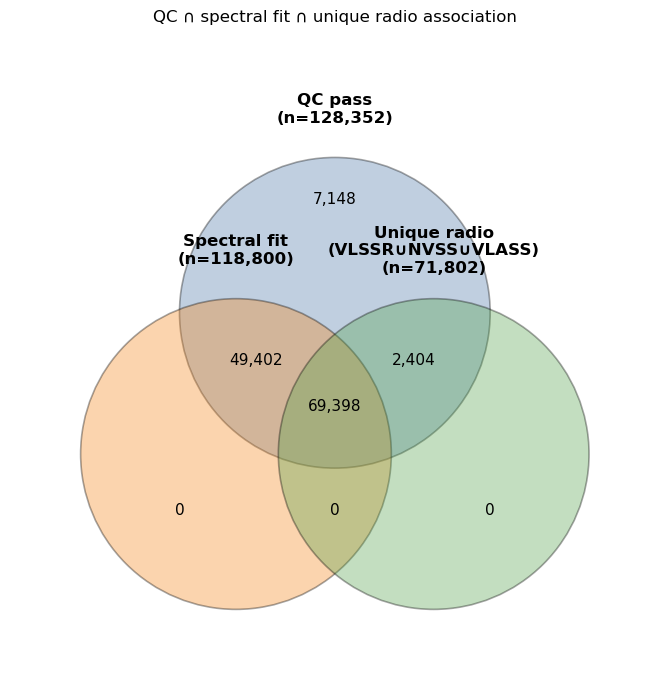

,region,count
0,QC only,7148
1,Spectral only (unexpected if spectral ⊆ QC),0
2,Radio only (outside QC),0
3,QC ∩ Spectral (not radio),49402
4,QC ∩ Radio (no spectral fit),2404
5,Spectral ∩ Radio (outside QC),0
6,QC ∩ Spectral ∩ Radio,69398
7,|QC ∩ Spectral|,118800
8,|QC ∩ Radio|,71802
9,|Spectral ∩ Radio|,69398


In [5]:
def venn3_counts(a: set, b: set, c: set) -> dict[str, int]:
    """Return labeled region counts for three sets (Abc, aBc, …, ABC)."""
    only_a = a - b - c
    only_b = b - a - c
    only_c = c - a - b
    ab = (a & b) - c
    ac = (a & c) - b
    bc = (b & c) - a
    abc = a & b & c
    return {
        "100": len(only_a),
        "010": len(only_b),
        "001": len(only_c),
        "110": len(ab),
        "101": len(ac),
        "011": len(bc),
        "111": len(abc),
        "|A|": len(a),
        "|B|": len(b),
        "|C|": len(c),
        "|A∩B|": len(a & b),
        "|A∩C|": len(a & c),
        "|B∩C|": len(b & c),
        "|A∩B∩C|": len(abc),
    }


def plot_venn3(
    counts: dict[str, int],
    *,
    labels: tuple[str, str, str] = ("A", "B", "C"),
    colors: tuple[str, str, str] = ("#4C78A8", "#F58518", "#54A24B"),
    ax: plt.Axes | None = None,
) -> plt.Axes:
    """Draw a schematic 3-circle Venn with region counts (areas not to scale)."""
    if ax is None:
        _, ax = plt.subplots(figsize=(7.5, 6.5))

    centers = ((0.0, 0.15), (-0.35, -0.35), (0.35, -0.35))
    radius = 0.55
    for (x, y), color, label in zip(centers, colors, labels, strict=True):
        ax.add_patch(
            Circle(
                (x, y),
                radius,
                facecolor=color,
                edgecolor="black",
                alpha=0.35,
                linewidth=1.2,
            )
        )
        ax.text(x, y + 0.72, label, ha="center", va="center", fontsize=12, fontweight="bold")

    # Approximate label positions for each region.
    positions = {
        "100": (0.0, 0.55),
        "010": (-0.55, -0.55),
        "001": (0.55, -0.55),
        "110": (-0.28, -0.02),
        "101": (0.28, -0.02),
        "011": (0.0, -0.55),
        "111": (0.0, -0.18),
    }
    for key, (x, y) in positions.items():
        ax.text(x, y, f"{counts[key]:,}", ha="center", va="center", fontsize=11)

    ax.set_xlim(-1.15, 1.15)
    ax.set_ylim(-1.15, 1.15)
    ax.set_aspect("equal")
    ax.axis("off")
    return ax


radio_ids = set(
    assoc.loc[
        (assoc["n_vlssr"] == 1) | (assoc["n_nvss"] == 1) | (assoc["n_vlass"] == 1),
        "meta_id",
    ].tolist()
)

set_qc = qc_ids
set_fit = fit_ids
set_radio = radio_ids

counts = venn3_counts(set_qc, set_fit, set_radio)
labels = (
    f"QC pass\n(n={counts['|A|']:,})",
    f"Spectral fit\n(n={counts['|B|']:,})",
    f"Unique radio\n(VLSSR∪NVSS∪VLASS)\n(n={counts['|C|']:,})",
)

fig, ax = plt.subplots(figsize=(8, 7))
plot_venn3(counts, labels=labels, ax=ax)
ax.set_title("QC ∩ spectral fit ∩ unique radio association")
plt.tight_layout()
plt.show()

overlap = pd.DataFrame(
    [
        {"region": "QC only", "count": counts["100"]},
        {"region": "Spectral only (unexpected if spectral ⊆ QC)", "count": counts["010"]},
        {"region": "Radio only (outside QC)", "count": counts["001"]},
        {"region": "QC ∩ Spectral (not radio)", "count": counts["110"]},
        {"region": "QC ∩ Radio (no spectral fit)", "count": counts["101"]},
        {"region": "Spectral ∩ Radio (outside QC)", "count": counts["011"]},
        {"region": "QC ∩ Spectral ∩ Radio", "count": counts["111"]},
        {"region": "|QC ∩ Spectral|", "count": counts["|A∩B|"]},
        {"region": "|QC ∩ Radio|", "count": counts["|A∩C|"]},
        {"region": "|Spectral ∩ Radio|", "count": counts["|B∩C|"]},
    ]
)
display(overlap)

### Optional: swap spectral set to χ²_red < 5

Re-run the next cell to redraw the Venn using good spectral fits instead of all fits.

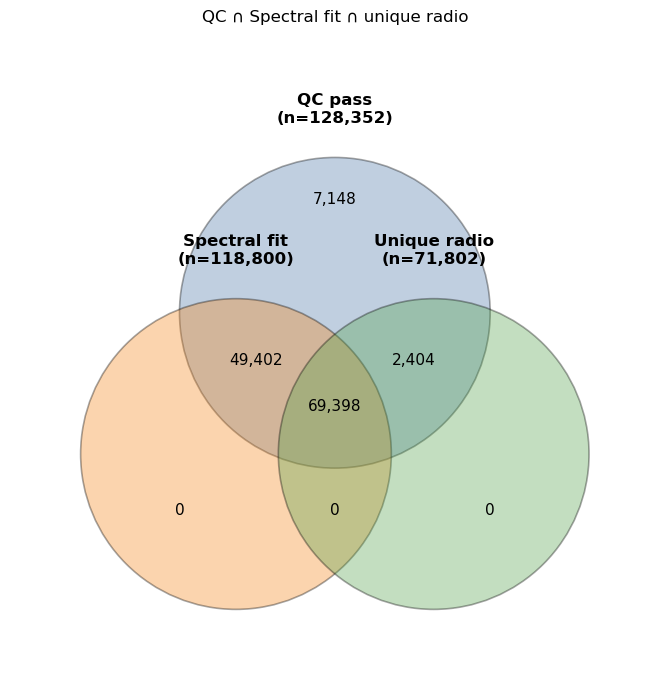

Triple intersection: 69,398  |  QC∩fit: 118,800  |  QC∩radio: 71,802  |  fit∩radio: 69,398


In [6]:
USE_GOOD_FIT_FOR_VENN = False  # True → spectral set = chi2_red < CHI2_RED_MAX

set_fit_venn = good_fit_ids if USE_GOOD_FIT_FOR_VENN else fit_ids
fit_label = (
    f"Spectral χ²_red < {CHI2_RED_MAX:g}"
    if USE_GOOD_FIT_FOR_VENN
    else "Spectral fit"
)
counts2 = venn3_counts(set_qc, set_fit_venn, set_radio)
labels2 = (
    f"QC pass\n(n={counts2['|A|']:,})",
    f"{fit_label}\n(n={counts2['|B|']:,})",
    f"Unique radio\n(n={counts2['|C|']:,})",
)
fig, ax = plt.subplots(figsize=(8, 7))
plot_venn3(counts2, labels=labels2, ax=ax)
ax.set_title(f"QC ∩ {fit_label} ∩ unique radio")
plt.tight_layout()
plt.show()
print(
    f"Triple intersection: {counts2['111']:,}  |  "
    f"QC∩fit: {counts2['|A∩B|']:,}  |  "
    f"QC∩radio: {counts2['|A∩C|']:,}  |  "
    f"fit∩radio: {counts2['|B∩C|']:,}"
)